In [2]:
# Imports
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sb

In [3]:
# Get data frome excel
df = pd.read_csv('American Players.csv')
df.head()

,Rk,Player,Pos,American?,G,From,To,Age,G.1,GS,...,AST%,STL%,BLK%,TOV%,USG%,Pos.1,eFG%,FGA,FTA,Team
0,1,Mikal Bridges,SG,Yes,401,2020-21,2024-25,24-28,401,401,...,12.5,1.5,1.5,8.7,19.5,F-G,0.564,5271,1076,"BRK,NYK,PHO"
1,2,Buddy Hield,SG,No,398,2020-21,2024-25,28-32,398,240,...,13.5,1.5,1.1,11.0,20.8,G-F,0.556,4764,483,"GSW,IND,PHI,SAC"
2,3,Georges Niang,PF,Yes,387,2020-21,2024-25,27-31,387,31,...,8.0,0.9,0.8,10.1,17.3,F,0.584,2722,245,"ATL,CLE,PHI,UTA"
3,4,Harrison Barnes,SF,Yes,381,2020-21,2024-25,28-32,381,381,...,8.7,1.0,0.4,8.6,16.9,F,0.575,3682,1456,"SAC,SAS"
4,5,Anthony Edwards,SG,Yes,381,2020-21,2024-25,19-23,381,363,...,19.6,1.8,1.6,12.0,29.5,G-F,0.524,7167,1976,MIN


In [4]:
# Get only American players
df = df[df['American?'] == 'Yes']
df

,Rk,Player,Pos,American?,G,From,To,Age,G.1,GS,...,AST%,STL%,BLK%,TOV%,USG%,Pos.1,eFG%,FGA,FTA,Team
0,1,Mikal Bridges,SG,Yes,401,2020-21,2024-25,24-28,401,401,...,12.5,1.5,1.5,8.7,19.5,F-G,0.564,5271,1076,"BRK,NYK,PHO"
2,3,Georges Niang,PF,Yes,387,2020-21,2024-25,27-31,387,31,...,8.0,0.9,0.8,10.1,17.3,F,0.584,2722,245,"ATL,CLE,PHI,UTA"
3,4,Harrison Barnes,SF,Yes,381,2020-21,2024-25,28-32,381,381,...,8.7,1.0,0.4,8.6,16.9,F,0.575,3682,1456,"SAC,SAS"
4,5,Anthony Edwards,SG,Yes,381,2020-21,2024-25,19-23,381,363,...,19.6,1.8,1.6,12.0,29.5,G-F,0.524,7167,1976,MIN
5,6,Royce O'Neale,SF,Yes,378,2020-21,2024-25,27-31,378,237,...,12.7,1.5,1.5,13.5,12.3,F,0.561,2540,232,"BRK,PHO,UTA"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,284,Taj Gibson,C,Yes,203,2020-21,2024-25,35-39,203,21,...,6.3,1.3,4.1,13.8,11.2,F-C,0.562,581,171,"CHO,DET,NYK,WAS"
284,285,Ochai Agbaji,SG,Yes,201,2022-23,2024-25,22-24,201,95,...,7.3,1.3,1.8,10.0,14.5,G,0.540,1353,173,"TOR,UTA"
285,286,Dāvis Bertāns,PF,Yes,201,2020-21,2023-24,28-31,201,9,...,5.5,1.2,1.2,6.1,16.6,F,0.559,1147,203,"CHO,DAL,OKC,WAS"
286,287,Thomas Bryant,C,Yes,200,2020-21,2024-25,23-27,200,57,...,6.7,1.0,3.2,9.0,18.0,C,0.616,1078,301,"DEN,IND,LAL,MIA,WAS"


In [ ]:
# Get correct stats for analysis
df['FT-RT'] = df['FTA']/df['FGA']
df['ORB%']=df['ORB%']/100
df['TOV%']=df['TOV%']/100
df = df[['Player','Pos', 'G', 'eFG%', 'ORB%', 'TOV%', 'FT-RT', 'BPM']]
df.head()

,Player,Pos,G,eFG%,ORB%,TOV%,FT-RT,BPM
0,Mikal Bridges,SG,401,0.564,0.029,0.087,0.204136,1.1
2,Georges Niang,PF,387,0.584,0.020,0.101,0.090007,-1.9
3,Harrison Barnes,SF,381,0.575,0.036,0.086,0.395437,-0.5
4,Anthony Edwards,SG,381,0.524,0.023,0.120,0.275708,1.7
5,Royce O'Neale,SF,378,0.561,0.033,0.135,0.091339,0.2


In [6]:
#Reset Index
df = df.reset_index(drop=True).iloc[:231]
df

,Player,Pos,G,eFG%,ORB%,TOV%,FT-RT,BPM
0,Mikal Bridges,SG,401,0.564,0.029,0.087,0.204136,1.1
1,Georges Niang,PF,387,0.584,0.020,0.101,0.090007,-1.9
2,Harrison Barnes,SF,381,0.575,0.036,0.086,0.395437,-0.5
3,Anthony Edwards,SG,381,0.524,0.023,0.120,0.275708,1.7
4,Royce O'Neale,SF,378,0.561,0.033,0.135,0.091339,0.2
...,...,...,...,...,...,...,...,...
226,Taj Gibson,C,203,0.562,0.103,0.138,0.294320,-1.8
227,Ochai Agbaji,SG,201,0.540,0.042,0.100,0.127864,-2.7
228,Dāvis Bertāns,PF,201,0.559,0.016,0.061,0.176983,-1.4
229,Thomas Bryant,C,200,0.616,0.089,0.090,0.279221,0.3


In [7]:
#Mean of stats per position
df.groupby(['Pos']).mean(numeric_only=True)

,G,eFG%,ORB%,TOV%,FT-RT,BPM
Pos,,,,,,
C,277.733333,0.600933,0.110200,0.131767,0.330206,0.630000
PF,279.906977,0.559535,0.060000,0.113047,0.254582,-0.079070
PG,293.791667,0.523979,0.024625,0.128062,0.225379,0.775000
SF,287.211538,0.546288,0.039269,0.105019,0.221390,-0.286538
SG,292.275862,0.545793,0.026017,0.104828,0.206278,-0.203448


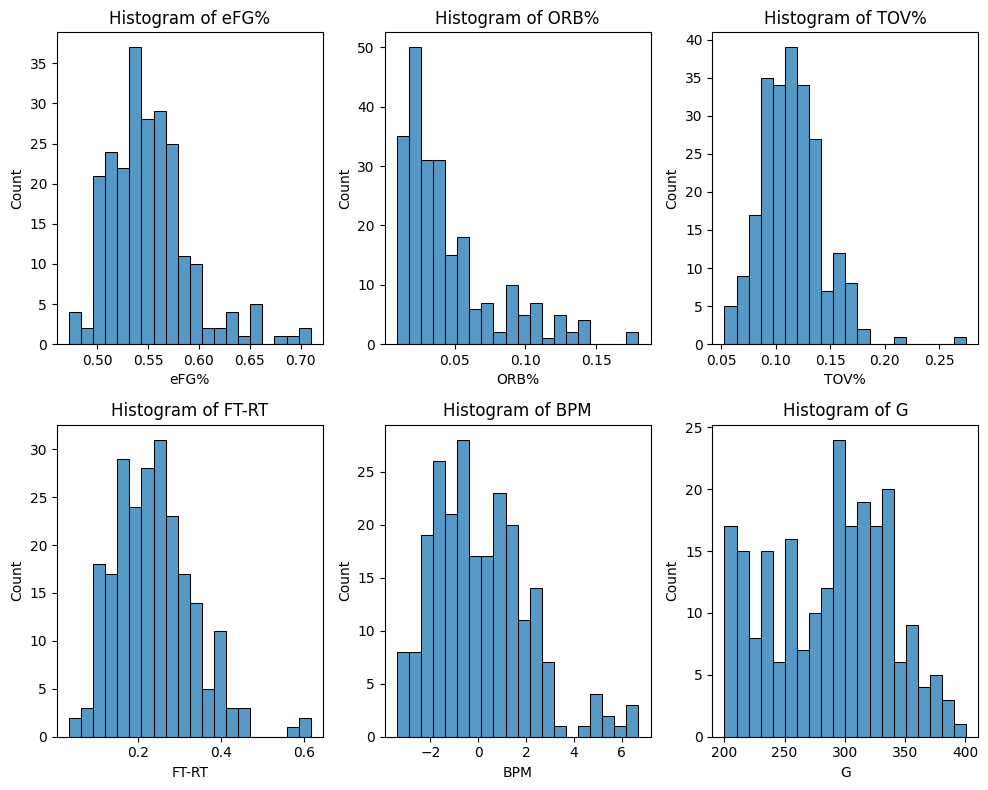

In [8]:
#Histograms of stats
df_plots = df[['eFG%', 'ORB%', 'TOV%', 'FT-RT', 'BPM', 'G']]
fig,axes = plt.subplots(2,3, figsize = (10,8))
axes = axes.flatten()
for i, col in enumerate(df_plots.columns):
    sb.histplot(df_plots[col], bins = 20, kde = False, ax = axes[i])
    axes[i].set_title(f'Histogram of {col}')
    
plt.tight_layout()
plt.show()

In [9]:
df.describe()

,G,eFG%,ORB%,TOV%,FT-RT,BPM
count,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000
mean,287.259740,0.551091,0.045970,0.114727,0.238735,0.112554
std,48.968065,0.040048,0.034193,0.028626,0.096506,1.981341
min,200.000000,0.472000,0.009000,0.053000,0.031800,-3.400000
25%,248.000000,0.523500,0.022000,0.095000,0.166181,-1.400000
50%,296.000000,0.546000,0.034000,0.113000,0.231570,-0.100000
75%,324.000000,0.570500,0.056000,0.130500,0.290307,1.250000
max,401.000000,0.710000,0.180000,0.275000,0.616877,6.700000


In [10]:
#Standardize the features
scaler = StandardScaler()
features = ['eFG%', 'ORB%', 'TOV%', 'FT-RT', 'BPM']

df[features] = scaler.fit_transform(df[features])
df_features = df[features]
df_features

,eFG%,ORB%,TOV%,FT-RT,BPM
0,0.323043,-0.497371,-0.970716,-0.359297,0.499455
1,0.823533,-0.761156,-0.480584,-1.544469,-1.017959
2,0.598313,-0.292206,-1.005726,1.627281,-0.309833
3,-0.677936,-0.673228,0.184595,0.383948,0.802938
4,0.247970,-0.380134,0.709737,-1.530645,0.044231
...,...,...,...,...,...
226,0.272994,1.671523,0.814765,0.577226,-0.967379
227,-0.277544,-0.116349,-0.515593,-1.151345,-1.422603
228,0.197921,-0.878393,-1.880961,-0.641262,-0.765057
229,1.624317,1.261192,-0.865688,0.420426,0.094811


IndexError: index 4 is out of bounds for axis 0 with size 4

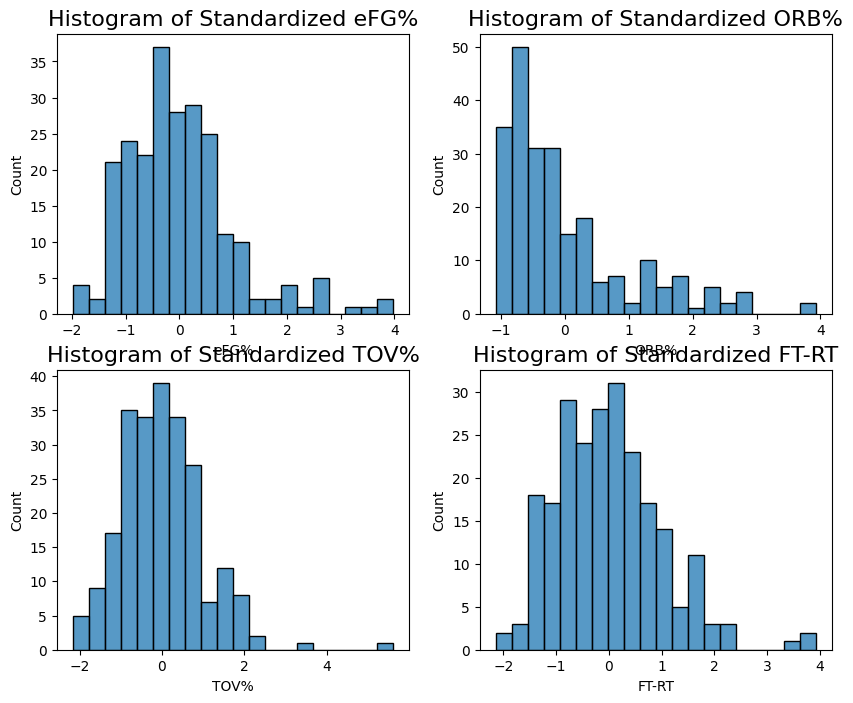

In [11]:
#Histograms of standardized features
fig,axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, col in enumerate(df_features.columns):
    sb.histplot(df_features[col], bins = 20, kde = False, ax = axes[i])
    axes[i].set_title(f'Histogram of Standardized {col}', fontsize = 16)
   
plt.tight_layout()
plt.show()

<Axes: >

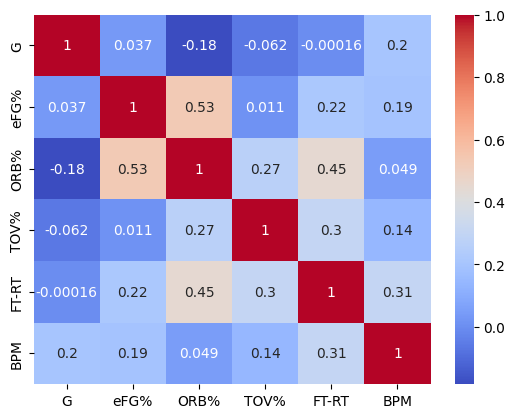

In [ ]:
#Correlation Heatmap
corr = df.corr(numeric_only = True)
sb.heatmap(corr, cmap="coolwarm", annot=True)

Text(0.5, 1.0, 'Boxplot for Relevant NBA Player Statistics')

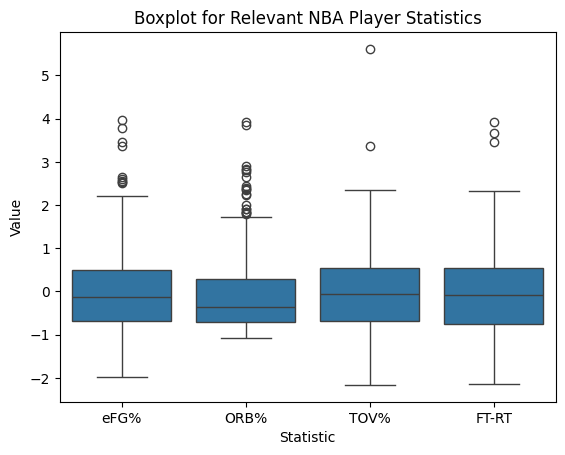

In [13]:
stat_columns = df[['eFG%','ORB%','TOV%', 'FT-RT']]
df_melted = stat_columns.melt(var_name='Statistic', value_name='Value')
sb.boxplot(x = 'Statistic', y = 'Value', data = df_melted)
plt.title("Boxplot for Relevant NBA Player Statistics")

In [14]:
network_data = df.copy()
network_data.to_csv("network_data.csv", index = False)